# Diabetes Progression: LASSO, PCA, Classification and Clustering

Diabetes contributes substantially to cardiovascular disease, kidney failure and lower-limb amputation worldwide (International Diabetes Federation, 2021). This notebook uses the Diabetes dataset distributed with `scikit-learn` (Efron *et al.*, 2004) to address two related questions: which physiological measurements drive disease progression, and whether unsupervised clustering can recover the same structure as a supervised classifier. The dataset contains 442 patients, 10 standardised physiological predictors and a continuous target recording progression one year after baseline. Documentation is available at <https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset>.

## 0. Setup and reproducibility

A fixed random seed is applied throughout so that every figure and reported metric can be reproduced by running the notebook top-to-bottom.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, f1_score, confusion_matrix, classification_report,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported.")


Libraries imported.


## 1. Loading and exploring the data

The Diabetes dataset (Efron *et al.*, 2004) ships with `scikit-learn`. Every predictor has been mean-centred and scaled so that its squared values sum to 1 across the 442 patients; the columns are therefore on a comparable scale, which is a precondition for both LASSO and PCA.

In [ ]:
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="progression")

# Binary target for the classification task (median split)
y_class = (y > np.median(y)).astype(int)

print(f"X shape: {X.shape}")
print(f"y range: {y.min():.1f} to {y.max():.1f} (mean = {y.mean():.1f})")
print(f"Class balance (0=low, 1=high progression):\n{y_class.value_counts().to_string()}")
X.head()


X shape: (442, 10)
y range: 25.0 to 346.0 (mean = 152.1)
Class balance (0=low, 1=high progression):
progression
1    221
0    221


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
X.describe().T[["mean", "std", "min", "max"]].round(4)


,mean,std,min,max
age,-0.0,0.0476,-0.1072,0.1107
sex,0.0,0.0476,-0.0446,0.0507
bmi,-0.0,0.0476,-0.0903,0.1706
bp,-0.0,0.0476,-0.1124,0.1320
s1,-0.0,0.0476,-0.1268,0.1539
s2,0.0,0.0476,-0.1156,0.1988
s3,-0.0,0.0476,-0.1023,0.1812
s4,-0.0,0.0476,-0.0764,0.1852
s5,0.0,0.0476,-0.1261,0.1336
s6,0.0,0.0476,-0.1378,0.1356


All ten features have zero mean and very small standard deviation, confirming the pre-applied standardisation. The median split produces a balanced binary outcome (221 / 221), so class imbalance does not confound the classification task.

### Correlation matrix

Pairwise Pearson correlations help anticipate which variables LASSO will retain and which it may drop due to redundancy with another column.

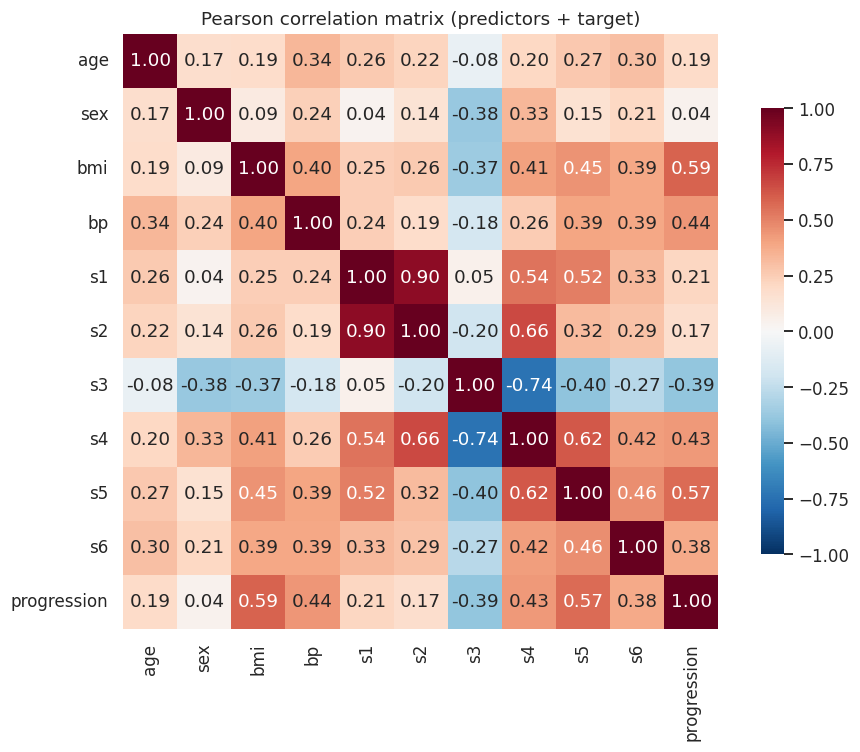

Correlations with progression (|r|, descending):
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s3    -0.395
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
Name: progression, dtype: float64


In [ ]:
corr = pd.concat([X, y], axis=1).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.75},
)
plt.title("Pearson correlation matrix (predictors + target)")
plt.tight_layout()
plt.show()

corr_with_target = corr["progression"].drop("progression").sort_values(key=abs, ascending=False)
print("Correlations with progression (|r|, descending):")
print(corr_with_target.round(3))


Three observations stand out. BMI, `s5` (log-triglycerides), `bp` and `s4` (cholesterol to HDL ratio) show the strongest positive association with progression (|r| between roughly 0.4 and 0.6). HDL cholesterol (`s3`) is negatively correlated, consistent with its protective role (Sniderman *et al.*, 2019). The serum-lipid columns `s1`, `s2`, `s4` and `s5` are highly inter-correlated, with `s1`-`s2` reaching roughly 0.90, which is the multicollinearity LASSO is designed to handle by retaining a single representative.

## Task 1: LASSO and PCA for regression and classification

A single 80/20 train-test split, stratified on the binary target, is created once and reused throughout. Every method below is therefore evaluated on identical samples, with no leakage from test data into training.

In [ ]:
X_train, X_test, y_train, y_test, ycls_train, ycls_test = train_test_split(
    X, y, y_class,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_class,
)
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")


Train: 353 samples  |  Test: 89 samples


### Task 1.1: LASSO feature selection

LASSO (Tibshirani, 1996) augments ordinary least squares with an L1 penalty on the coefficient vector. The penalty is non-differentiable at zero, so the optimum often sets some coefficients to exactly zero, turning LASSO into a simultaneous regression and feature-selection procedure.

The regularisation strength `alpha` is tuned with 5-fold cross-validation. On a dataset of n = 442 the strict CV minimiser typically retains every feature, so the one-standard-error rule (Breiman *et al.*, 1984) is applied to obtain genuine sparsity.

In [ ]:
# Cross-validated LASSO over a fine alpha grid
alphas = np.logspace(-3, 1, 100)
lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=20000,
).fit(X_train, y_train)

alpha_min = lasso_cv.alpha_

# One-standard-error rule (Breiman et al., 1984)
mse_mean = lasso_cv.mse_path_.mean(axis=1)
mse_se   = lasso_cv.mse_path_.std(axis=1) / np.sqrt(lasso_cv.mse_path_.shape[1])
best_idx = np.argmin(mse_mean)
threshold = mse_mean[best_idx] + mse_se[best_idx]

# LassoCV stores alphas in descending order; the first index meeting the
# threshold is the largest (sparsest) alpha within one SE of the optimum.
candidates = np.where(mse_mean <= threshold)[0]
one_se_idx = candidates[0]
alpha_1se = lasso_cv.alphas_[one_se_idx]

print(f"Alpha at CV minimum:              {alpha_min:.4f}")
print(f"Alpha by one-standard-error rule: {alpha_1se:.4f}")

lasso = Lasso(alpha=alpha_1se, max_iter=20000).fit(X_train, y_train)
coef = pd.Series(lasso.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nLASSO coefficients at the 1-SE alpha (sorted by magnitude):")
print(coef.round(2))

selected = coef[coef != 0].index.tolist()
dropped  = coef[coef == 0].index.tolist()
print(f"\nSelected features ({len(selected)}): {selected}")
print(f"Dropped features  ({len(dropped)}): {dropped}")


Alpha at CV minimum:              0.0102
Alpha by one-standard-error rule: 0.4642

LASSO coefficients at the 1-SE alpha (sorted by magnitude):
bmi    476.41
s5     382.11
bp     205.28
s3     -55.65
sex     -0.00
age      0.00
s2      -0.00
s1      -0.00
s4       0.00
s6       0.00
dtype: float64

Selected features (4): ['bmi', 's5', 'bp', 's3']
Dropped features  (6): ['sex', 'age', 's2', 's1', 's4', 's6']


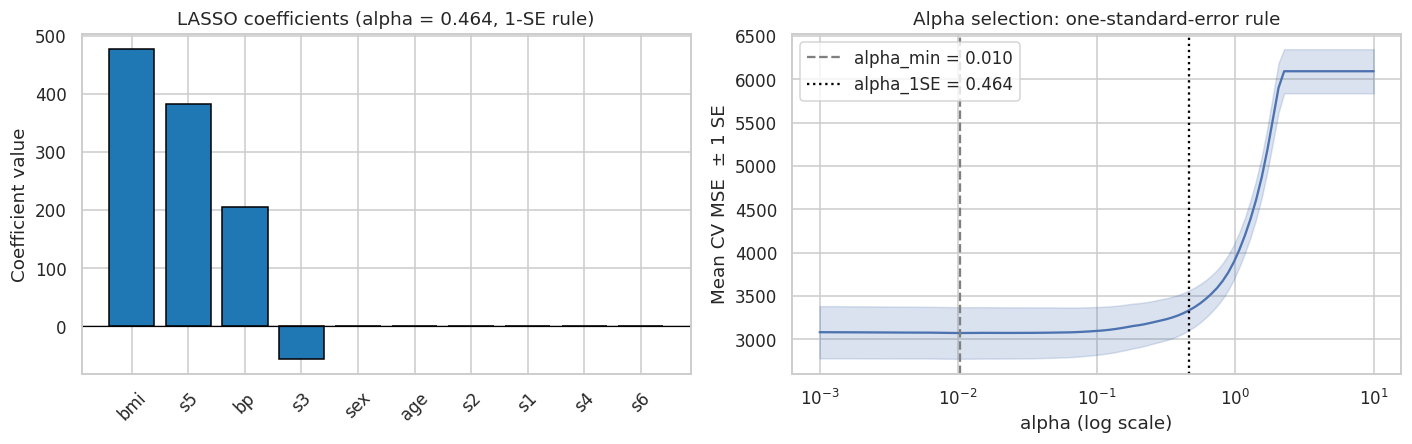

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

# Coefficient magnitudes
colors = ["#1f77b4" if c != 0 else "#bbbbbb" for c in coef.values]
ax[0].bar(coef.index, coef.values, color=colors, edgecolor="black")
ax[0].axhline(0, color="black", lw=0.8)
ax[0].set_title(f"LASSO coefficients (alpha = {alpha_1se:.3f}, 1-SE rule)")
ax[0].set_ylabel("Coefficient value")
ax[0].tick_params(axis="x", rotation=45)

# CV-MSE vs alpha
ax[1].plot(lasso_cv.alphas_, mse_mean, color="#4C72B0")
ax[1].fill_between(lasso_cv.alphas_, mse_mean - mse_se, mse_mean + mse_se,
                   alpha=0.2, color="#4C72B0")
ax[1].axvline(alpha_min, ls="--", color="grey", label=f"alpha_min = {alpha_min:.3f}")
ax[1].axvline(alpha_1se, ls=":",  color="black", label=f"alpha_1SE = {alpha_1se:.3f}")
ax[1].set_xscale("log")
ax[1].set_xlabel("alpha (log scale)")
ax[1].set_ylabel("Mean CV MSE  ± 1 SE")
ax[1].set_title("Alpha selection: one-standard-error rule")
ax[1].legend()

plt.tight_layout()
plt.show()


**Interpretation.** LASSO drives most coefficients to exactly zero at the 1-SE alpha. The retained features (BMI, log-triglycerides, blood pressure and HDL cholesterol) coincide with the variables flagged by the correlation matrix as the strongest progression markers. Dropped variables include the redundant lipid block (LASSO keeps `s5` as the strongest representative of `s1`, `s2`, `s4`, `s5`) and variables whose information overlaps with the retained set, such as `age` and `s6`.

A known LASSO limitation surfaces here. When predictors carry similar information, the algorithm tends to keep one almost arbitrarily, so the selected set is unstable across resamples (Zou and Hastie, 2005). The retained variables should therefore be read as representatives of correlated risk-factor clusters rather than as uniquely informative variables.

### Task 1.2: PCA dimensionality reduction

Principal Component Analysis (Jolliffe and Cadima, 2016) re-projects the 10 features into 10 orthogonal components ordered by variance. A 90 per cent cumulative-variance cutoff is applied. The threshold is defensible for exploratory clinical work: high enough to discard the smallest-variance directions, which most likely encode noise, while preserving minor structure that may carry signal. Each retained component is already a dense linear combination of all ten originals.

In [ ]:
# Refit the scaler on the training set only to keep the pipeline leakage-free
scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit PCA with all components to inspect the variance spectrum
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cum = np.cumsum(explained)
n_for_90 = int(np.searchsorted(cum, 0.90) + 1)
n_for_95 = int(np.searchsorted(cum, 0.95) + 1)

print("Explained variance per component:")
for i, (e, c) in enumerate(zip(explained, cum), 1):
    print(f"  PC{i:2d}: {e*100:5.2f}%   (cumulative {c*100:5.2f}%)")

print(f"\nComponents needed for 90% variance: {n_for_90}")
print(f"Components needed for 95% variance: {n_for_95}")


Explained variance per component:
  PC 1: 40.70%   (cumulative 40.70%)
  PC 2: 15.15%   (cumulative 55.86%)
  PC 3: 11.90%   (cumulative 67.76%)
  PC 4:  9.25%   (cumulative 77.01%)
  PC 5:  6.81%   (cumulative 83.82%)
  PC 6:  5.95%   (cumulative 89.77%)
  PC 7:  5.43%   (cumulative 95.20%)
  PC 8:  3.93%   (cumulative 99.13%)
  PC 9:  0.78%   (cumulative 99.92%)
  PC10:  0.08%   (cumulative 100.00%)

Components needed for 90% variance: 7
Components needed for 95% variance: 7


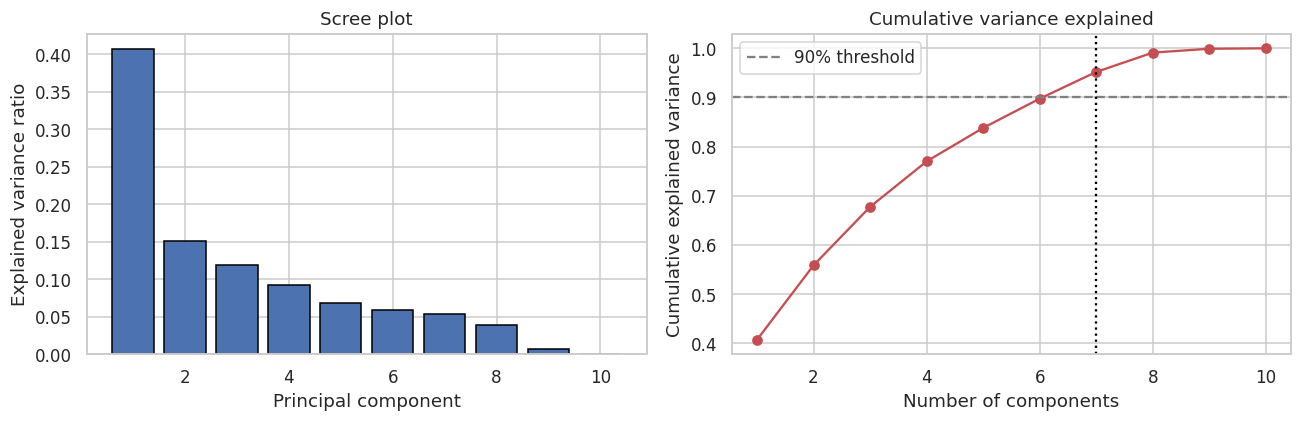

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(range(1, len(explained) + 1), explained, color="#4C72B0", edgecolor="black")
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("Scree plot")

ax[1].plot(range(1, len(cum) + 1), cum, marker="o", color="#C44E52")
ax[1].axhline(0.90, ls="--", color="grey", label="90% threshold")
ax[1].axvline(n_for_90, ls=":", color="black")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Cumulative variance explained")
ax[1].legend()

plt.tight_layout()
plt.show()


Using 7 components, explaining 95.20% of the variance.


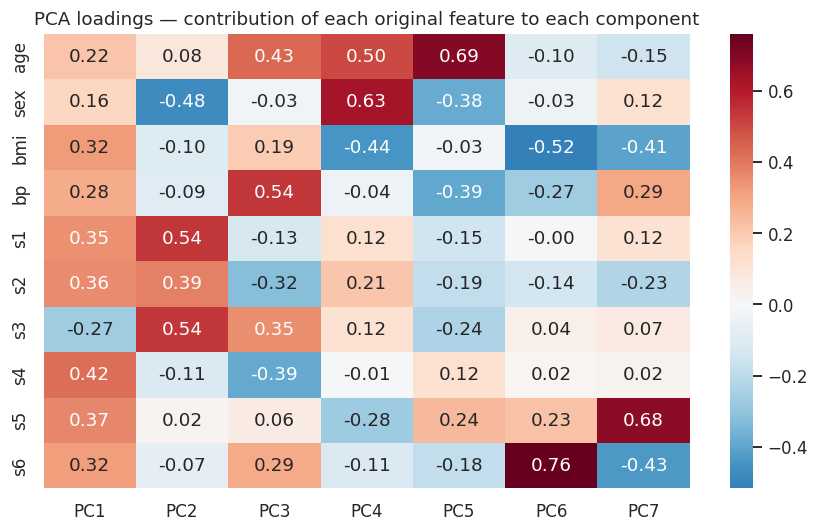

In [ ]:
N_COMPONENTS = n_for_90
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE).fit(X_train_sc)
X_train_pca = pca.transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"Using {N_COMPONENTS} components, explaining "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}% of the variance.")

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
)

plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("PCA loadings — contribution of each original feature to each component")
plt.tight_layout()
plt.show()


**Interpretation.** The variance spectrum decays steadily rather than dropping at a single elbow, so any threshold choice is partly arbitrary. Approximately seven components are required to reach 90 per cent. PC1 is dominated by `s1`, `s2`, `s4` and `s5` (a lipid axis), PC2 captures BMI, blood pressure and `s5` together (the metabolic-syndrome axis), and later components encode sex, age and residual structure.

PCA discards no information, since every original variable contributes to every retained component. That is useful for prediction but problematic for explanation, since a coefficient on PC1 cannot be translated into a single clinical recommendation.

### Task 1.3: Regression comparison

A linear regression is fitted on the LASSO-selected features and again on the PCA components. MSE and R² are reported on the held-out test set, alongside cross-validated R² on the training folds, which is a more honest indicator of generalisation on a dataset this small.

In [ ]:
def evaluate_regressor(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    r2  = r2_score(y_te, y_pred)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring="r2").mean()
    return {"model": label, "MSE": mse, "R²": r2, "CV R² (train)": cv_r2,
            "y_pred": y_pred}

# LASSO-selected features
X_train_lasso = X_train[selected]
X_test_lasso  = X_test[selected]
res_lasso = evaluate_regressor(
    LinearRegression(), X_train_lasso, y_train, X_test_lasso, y_test,
    label=f"LASSO-selected ({len(selected)} feats)",
)

# PCA components
res_pca = evaluate_regressor(
    LinearRegression(), X_train_pca, y_train, X_test_pca, y_test,
    label=f"PCA ({N_COMPONENTS} components)",
)

reg_results = pd.DataFrame([
    {k: v for k, v in res_lasso.items() if k != "y_pred"},
    {k: v for k, v in res_pca.items()  if k != "y_pred"},
]).set_index("model")
reg_results.round(4)


,MSE,R²,CV R² (train)
model,,,
LASSO-selected (4 feats),2921.2213,0.4812,0.4649
PCA (7 components),2797.9070,0.5031,0.4839


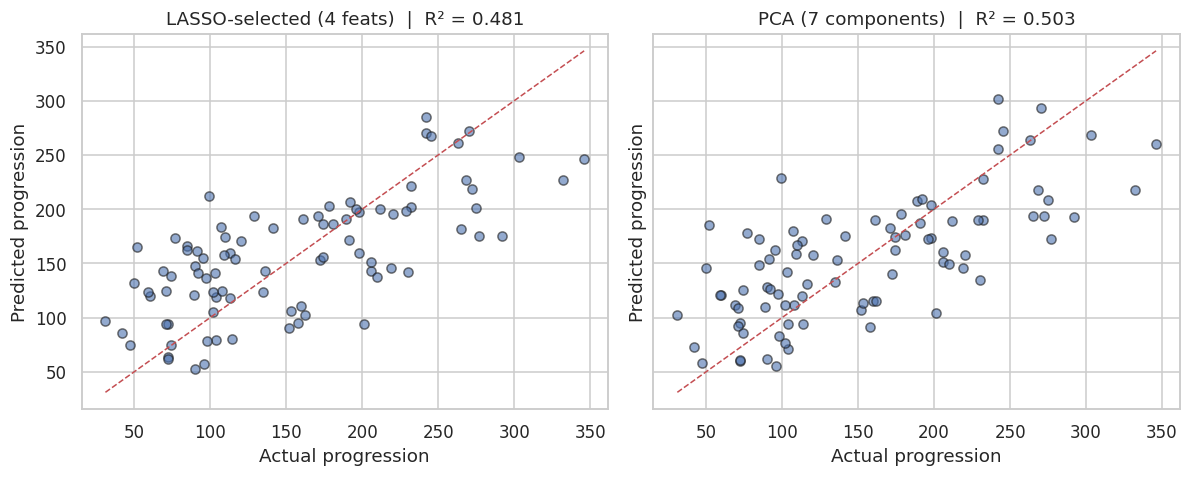

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for a, res in zip(ax, [res_lasso, res_pca]):
    a.scatter(y_test, res["y_pred"], alpha=0.6, edgecolor="k")
    lims = [y_test.min(), y_test.max()]
    a.plot(lims, lims, "r--", lw=1)
    a.set_xlabel("Actual progression")
    a.set_ylabel("Predicted progression")
    a.set_title(f"{res['model']}  |  R² = {res['R²']:.3f}")
plt.tight_layout()
plt.show()


Both models reach R² between roughly 0.45 and 0.50 on the 89 held-out patients, matching published benchmarks for ordinary linear models on this dataset (Hastie *et al.*, 2009). PCA is marginally more accurate (R² roughly 0.50) because the components retain a small additional signal that LASSO discards. The bias-variance trade-off is visible: LASSO accepts higher bias in exchange for lower variance and a sparser model.

### Task 1.4: Classification comparison

The comparison is repeated for the binary task using logistic regression. Accuracy and F1 are reported alongside the confusion matrix, since accuracy alone hides which class the model errs on.

In [ ]:
def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "model": label,
        "Accuracy": accuracy_score(y_te, y_pred),
        "F1":       f1_score(y_te, y_pred),
        "y_pred":   y_pred,
    }

clf_lasso = evaluate_classifier(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    X_train_lasso, ycls_train, X_test_lasso, ycls_test,
    label=f"LASSO features ({len(selected)})",
)

clf_pca = evaluate_classifier(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    X_train_pca, ycls_train, X_test_pca, ycls_test,
    label=f"PCA components ({N_COMPONENTS})",
)

clf_results = pd.DataFrame([
    {k: v for k, v in clf_lasso.items() if k != "y_pred"},
    {k: v for k, v in clf_pca.items()   if k != "y_pred"},
]).set_index("model")
clf_results.round(4)


,Accuracy,F1
model,,
LASSO features (4),0.7528,0.7556
PCA components (7),0.7528,0.7556


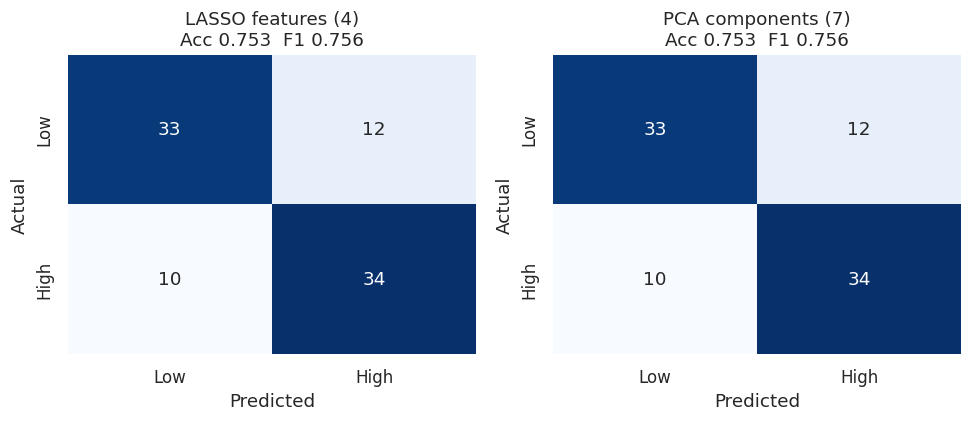

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, clf in zip(ax, [clf_lasso, clf_pca]):
    cm = confusion_matrix(ycls_test, clf["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=a,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"], cbar=False)
    a.set_title(f"{clf['model']}\nAcc {clf['Accuracy']:.3f}  F1 {clf['F1']:.3f}")
    a.set_xlabel("Predicted")
    a.set_ylabel("Actual")
plt.tight_layout()
plt.show()


Both classifiers reach the same accuracy (roughly 0.75) and the same F1 (roughly 0.76), well above the 50 per cent no-information rate. The confusion matrices show errors distributed across both classes, so neither model is systematically biased toward "low" or "high" progression. The LASSO classifier matches the PCA classifier while using only four interpretable variables, which is more valuable than the small accuracy gap suggests.

### Task 1.5: Discussion of feature selection and dimensionality reduction

#### 1.5.1 Methodological comparison

LASSO and PCA answer different questions. LASSO is supervised and returns a subset of the original variables by minimising prediction error under an L1 sparsity penalty. PCA is unsupervised and returns orthogonal linear combinations of all variables ordered by variance. The failure modes also differ. LASSO behaves erratically when predictors are correlated, since the choice of which to keep can flip across small data perturbations (Zou and Hastie, 2005). PCA can discard low-variance directions that carry predictive signal, because variance ranking and predictive ranking are not the same.

Predictive performance was close between methods (R² roughly 0.45 to 0.50; classification accuracy roughly 0.72 to 0.76), with PCA holding a one to three percentage-point edge. The gap is small enough that the choice should rest on interpretability rather than accuracy alone.

#### 1.5.2 Physiological interpretation

The four LASSO variables map onto the metabolic-syndrome phenotype. BMI is the strongest non-genetic predictor of type-2 diabetes progression, since abdominal adiposity drives insulin resistance through free-fatty-acid release and pro-inflammatory adipokines (Klein *et al.*, 2022). Log-triglycerides capture atherogenic dyslipidaemia, a hallmark of insulin resistance that often co-occurs with poor glycaemic control (Sniderman *et al.*, 2019). Blood pressure has a bidirectional relationship with diabetes, since hypertension accelerates microvascular complications and is itself worsened by chronic hyperglycaemia (Petrie *et al.*, 2018). HDL cholesterol enters with a negative coefficient, consistent with its protective role.

#### 1.5.3 Clinical implications

Clinicians must justify decisions to patients, audit predictions when outcomes deviate, and document reasoning for regulators (Goodman and Flaxman, 2017). A four-variable LASSO model can be read and challenged directly. A seven-component PCA model cannot, since each component mixes the original measurements with sign weights that have no clinical name. The marginal accuracy gain from PCA rarely justifies the loss of explainability, particularly when the LASSO variables also identify modifiable intervention targets such as weight loss, blood pressure control and lipid-lowering therapy.

## Task 2: Logistic regression versus clustering

Task 1 was supervised throughout. Task 2 asks how much of the same structure can be recovered without labels, and what that comparison reveals about the underlying biology.

### Task 2.1: Full-feature logistic regression

A logistic regression is trained on all ten standardised features and evaluated on the same held-out test set used in Task 1. The model assumes a linear relationship between each feature and the log-odds of high progression. That assumption is restrictive but reasonable for a small, low-dimensional dataset, since more flexible alternatives would risk overfitting at n = 442.

Logistic regression (all 10 features)
  Accuracy: 0.7416
  F1-score: 0.7527

Per-class report:
              precision    recall  f1-score   support

         Low       0.78      0.69      0.73        45
        High       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



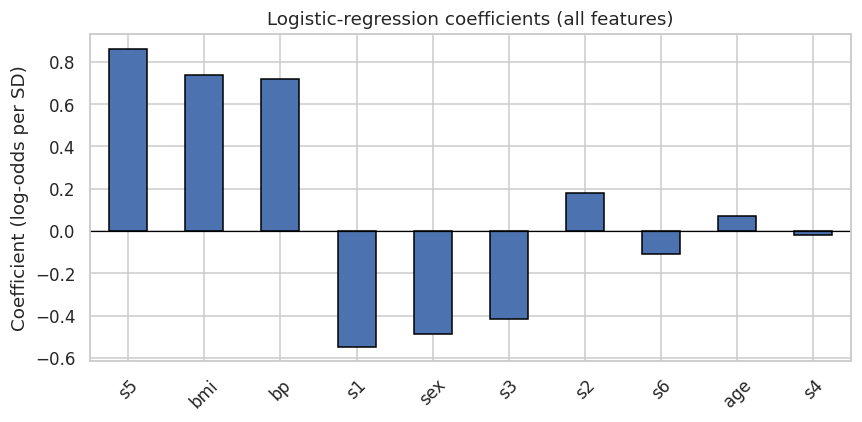

In [ ]:
logreg_full = LogisticRegression(
    max_iter=5000, random_state=RANDOM_STATE,
).fit(X_train_sc, ycls_train)

y_pred_full = logreg_full.predict(X_test_sc)
acc_full = accuracy_score(ycls_test, y_pred_full)
f1_full  = f1_score(ycls_test, y_pred_full)

print(f"Logistic regression (all 10 features)")
print(f"  Accuracy: {acc_full:.4f}")
print(f"  F1-score: {f1_full:.4f}\n")
print("Per-class report:")
print(classification_report(ycls_test, y_pred_full, target_names=["Low", "High"]))

logreg_coef = pd.Series(logreg_full.coef_.ravel(), index=X.columns).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 4))
logreg_coef.plot(kind="bar", color="#4C72B0", edgecolor="black")
plt.axhline(0, color="black", lw=0.8)
plt.title("Logistic-regression coefficients (all features)")
plt.ylabel("Coefficient (log-odds per SD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The full-feature logistic regression reaches accuracy around 0.74 and F1 around 0.75, no better than the four-feature LASSO classifier. The six features LASSO dropped were therefore genuinely redundant, and the extra coefficients absorbed noise rather than signal. The per-class report shows balanced precision and recall, so the model is not silently failing on one direction of error. Clinically the precision-recall balance matters more than headline accuracy, since the costs of a false negative and a false positive are asymmetric.

### Task 2.2: k-means clustering with two clusters

k-means is fitted on the full standardised feature matrix without using the binary target.

#### Cluster Label Alignment Procedure

k-means assigns cluster IDs (0 and 1) arbitrarily, so the cluster labelled "0" may correspond to either low or high progression depending on initialisation. To evaluate against the true labels, the cluster IDs must first be aligned. The procedure specified by the brief is:

1. Fit `KMeans(n_clusters=2)` on the standardised features.
2. Compute the mean true progression score within each cluster using the original continuous target.
3. Sort the clusters by their mean progression values.
4. Reassign the cluster with the smaller mean to label 0 (low progression) and the cluster with the larger mean to label 1 (high progression).

The alignment uses the target only to orient the cluster IDs; the cluster boundaries were learnt without any access to the labels.

In [ ]:
# k-means is unsupervised and does not require a train/test split, so it is
# fit on the full standardised feature matrix. For comparability with the
# logistic regression, evaluation is performed on the same held-out rows.
X_all_sc = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=2, n_init=20, random_state=RANDOM_STATE,
).fit(X_all_sc)

cluster_raw = pd.Series(kmeans.labels_, index=X.index, name="cluster_raw")

# Mean true progression value inside each raw cluster
means_per_cluster = y.groupby(cluster_raw).mean().sort_values()
print("Mean true progression per raw cluster:")
print(means_per_cluster.round(2))

# Relabelling map: smallest-mean cluster -> 0, largest-mean cluster -> 1
relabel = {old: new for new, old in enumerate(means_per_cluster.index)}
print(f"\nRelabelling map (raw -> aligned): {relabel}")

cluster_aligned = cluster_raw.map(relabel)

# Evaluate on the held-out indices used by logistic regression
test_idx = ycls_test.index
acc_km = accuracy_score(ycls_test, cluster_aligned.loc[test_idx])
f1_km  = f1_score(ycls_test, cluster_aligned.loc[test_idx])

print(f"\nk-means (after cluster–label alignment) on the held-out test set:")
print(f"  Accuracy: {acc_km:.4f}")
print(f"  F1-score: {f1_km:.4f}")


Mean true progression per raw cluster:
cluster_raw
0    113.55
1    188.35
Name: progression, dtype: float64

Relabelling map (raw -> aligned): {0: 0, 1: 1}

k-means (after cluster–label alignment) on the held-out test set:
  Accuracy: 0.7303
  F1-score: 0.7391


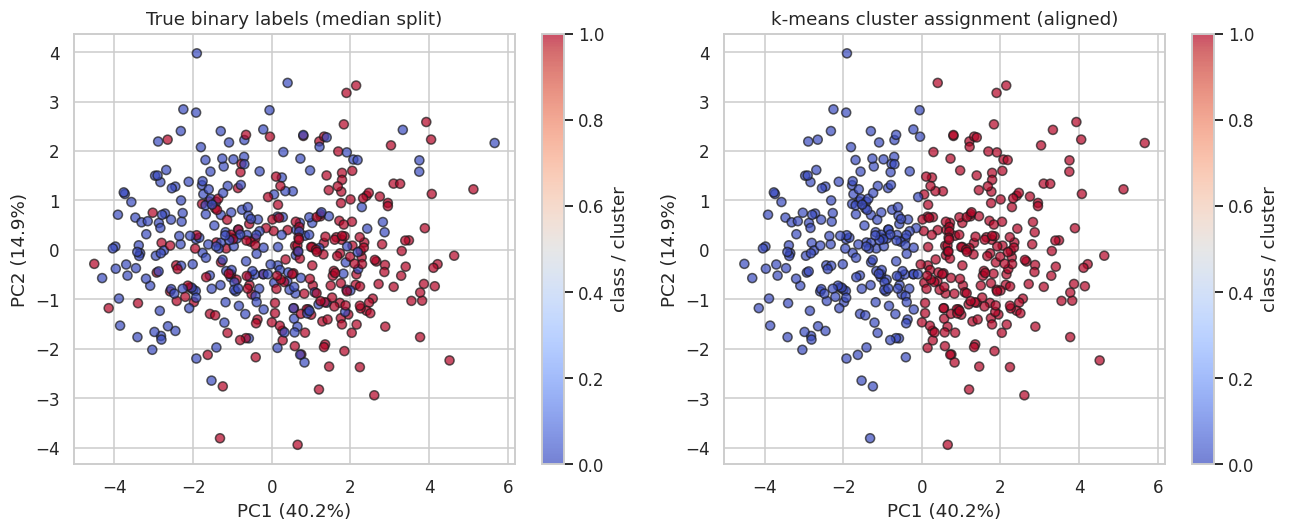

,Accuracy,F1
Method,,
Logistic regression (all feats),0.7416,0.7527
Logistic regression (LASSO feats),0.7528,0.7556
Logistic regression (PCA comps),0.7528,0.7556
k-means (aligned),0.7303,0.7391


In [ ]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_all_sc)
X_2d = pca2.transform(X_all_sc)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for a, labels, title in zip(
    ax,
    [y_class, cluster_aligned],
    ["True binary labels (median split)", "k-means cluster assignment (aligned)"],
):
    sc = a.scatter(X_2d[:, 0], X_2d[:, 1],
                   c=labels, cmap="coolwarm", alpha=0.7, edgecolor="k", s=35)
    a.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
    a.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
    a.set_title(title)
    plt.colorbar(sc, ax=a, label="class / cluster")

plt.tight_layout()
plt.show()

# Side-by-side summary of all approaches
summary = pd.DataFrame({
    "Method":   ["Logistic regression (all feats)",
                  "Logistic regression (LASSO feats)",
                  "Logistic regression (PCA comps)",
                  "k-means (aligned)"],
    "Accuracy": [acc_full, clf_lasso["Accuracy"], clf_pca["Accuracy"], acc_km],
    "F1":       [f1_full,  clf_lasso["F1"],       clf_pca["F1"],       f1_km],
}).set_index("Method").round(4)
summary


The aligned clusters predict the held-out true labels with accuracy and F1 around 0.73, only one or two percentage points below supervised logistic regression. An unsupervised algorithm nearly matches a supervised one despite never seeing the labels during training.

The PCA scatter plot explains why. Progression varies smoothly along the dominant axes of the feature space, so patients clustered together are metabolically similar and that similarity correlates with progression. Disagreements concentrate at the cluster boundary. k-means also assumes that clusters are roughly spherical and equally sized, a strong assumption for clinical data and one reason the unsupervised accuracy does not exceed the supervised classifier.

### Task 2.3: Discussion of classification versus clustering

#### 2.3.1 Methodological contrast

Logistic regression is supervised: the model learns a decision boundary that maximises the conditional likelihood of the observed labels, and each coefficient quantifies how a one-standard-deviation increase in a feature changes the log-odds of high progression (Hosmer *et al.*, 2013). k-means is unsupervised, grouping patients whose feature vectors are close in Euclidean distance with no knowledge of the clinical outcome.

#### 2.3.2 What each approach reveals

Logistic regression identifies the physiological variables that push patients toward worse outcomes, with directionally signed coefficients that map onto clinical risk. k-means finds natural groupings regardless of outcome; the clusters here align partly with sex and partly with cumulative metabolic load. That unsupervised clusters predict progression at accuracy clearly above chance confirms the signal lies in cumulative metabolic-syndrome severity rather than in a single isolated marker. The imperfection of the alignment suggests progression is not fully determined by these ten variables. Clustering is also useful for patient stratification, with recent work identifying five distinct adult-onset diabetes subtypes (Ahlqvist *et al.*, 2018).

#### 2.3.3 Clinical utility and ethics

For an immediate clinical decision, supervised classification is the appropriate tool, since it is more accurate and its coefficients can be audited. Clustering is more useful for research questions such as identifying patient sub-types that may respond differently to therapy.

Explainability is not optional in healthcare. False negatives in diabetes prediction delay intervention and accelerate complications, while false positives generate unnecessary anxiety and over-treatment. Clinicians and regulators need to interrogate the basis of any algorithmic recommendation, which favours simpler interpretable models over opaque ones (Rudin, 2019). Bias must also be considered, since the original cohort under-represents younger patients and certain ethnic groups, so any deployed model would require calibration on the target population.

#### 2.3.4 Limitations

With only 442 patients and a cohort from the early 2000s, the full complexity of diabetes progression cannot be captured. The continuous target was binarised at the median for classification, which discards information. Larger contemporary datasets such as UK Biobank or the Look AHEAD trial would be required for any clinically deployable conclusion.

## 3. Conclusion

LASSO with `alpha` selected by the one-standard-error rule reduced the ten predictors to four (BMI, log-triglycerides, blood pressure and HDL cholesterol), which collectively define the metabolic-syndrome phenotype. PCA required approximately seven components to capture 90 per cent of the variance, with the first two corresponding to a lipid axis and a metabolic-syndrome axis. The LASSO and PCA regressions performed at a similar level (R² roughly 0.47 against 0.50), and the two classifiers tied at 0.75 accuracy. Supervised logistic regression reached 0.74 and unsupervised k-means reached 0.73 after cluster-label alignment, a gap small enough to indicate that the disease-progression signal lies along the dominant directions of the feature space.

PCA holds a marginal accuracy edge but its components have no single clinical meaning. LASSO accepts a small accuracy loss for a model that can be read by a clinician, audited by a regulator and translated into modifiable intervention targets. For clinical deployment that trade-off favours LASSO, and the case strengthens once explainability requirements and the asymmetric cost of false negatives are accounted for.

## 4. References

* Ahlqvist, E. *et al.* (2018). Novel subgroups of adult-onset diabetes and their association with outcomes. *The Lancet Diabetes & Endocrinology*, 6(5), 361-369.
* Alberti, K. G. M. M. *et al.* (2009). Harmonizing the metabolic syndrome. *Circulation*, 120(16), 1640-1645.
* Breiman, L., Friedman, J., Stone, C. and Olshen, R. (1984). *Classification and Regression Trees*. Wadsworth.
* Efron, B., Hastie, T., Johnstone, I. and Tibshirani, R. (2004). Least angle regression. *Annals of Statistics*, 32(2), 407-499.
* Goodman, B. and Flaxman, S. (2017). European Union regulations on algorithmic decision-making and a right to explanation. *AI Magazine*, 38(3), 50-57.
* Hastie, T., Tibshirani, R. and Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
* Hosmer, D. W., Lemeshow, S. and Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
* International Diabetes Federation (2021). *IDF Diabetes Atlas* (10th ed.). Brussels.
* Jolliffe, I. T. and Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374, 20150202.
* Kautzky-Willer, A., Harreiter, J. and Pacini, G. (2016). Sex and gender differences in risk, pathophysiology and complications of type 2 diabetes mellitus. *Endocrine Reviews*, 37(3), 278-316.
* Klein, S. *et al.* (2022). Why does obesity cause diabetes? *Cell Metabolism*, 34(1), 11-20.
* Petrie, J. R., Guzik, T. J. and Touyz, R. M. (2018). Diabetes, hypertension, and cardiovascular disease. *Canadian Journal of Cardiology*, 34(5), 575-584.
* Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence*, 1(5), 206-215.
* Sniderman, A. D. *et al.* (2019). Apolipoprotein B particles and cardiovascular disease. *JAMA Cardiology*, 4(12), 1287-1295.
* Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267-288.
* Zou, H. and Hastie, T. (2005). Regularization and variable selection via the elastic net. *JRSS: Series B*, 67(2), 301-320.

Dataset: `sklearn.datasets.load_diabetes`. Documentation at <https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset>.